# Logistic Regression – Diabetes Prediction

Name: Ashar Khan
Batch: Data Science Weekday – Hyderabad  

In this assignment, we analyze a healthcare dataset to predict whether a person has diabetes or not. We use logistic regression, which is a classification technique, to understand how different medical features such as glucose level, BMI, and age affect the chances of diabetes. The goal is to build a model that can classify outcomes clearly and help in decision-making.

## Importing Required Libraries

In this step, we import the necessary libraries for data analysis, visualization, and model building. These libraries help us load the dataset, process the data, build machine learning models, and evaluate their performance in a structured and efficient way.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In this step, we load the diabetes dataset which contains various medical details of patients. The dataset includes features such as glucose level, blood pressure, BMI, age, and a target variable indicating whether the patient has diabetes or not.

In [ ]:
df = pd.read_csv(r"C:\Users\tausi\Downloads\diabetes.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Exploratory Data Analysis

In this step, we take a first look at the dataset to understand what kind of information it contains. We check how the values are distributed and whether any values look unusual. For example, we can see if most patients have similar glucose levels or if there are extreme cases. We also check how different features are related to each other. This step is important because it helps us understand the data before building any model and avoids mistakes later.

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


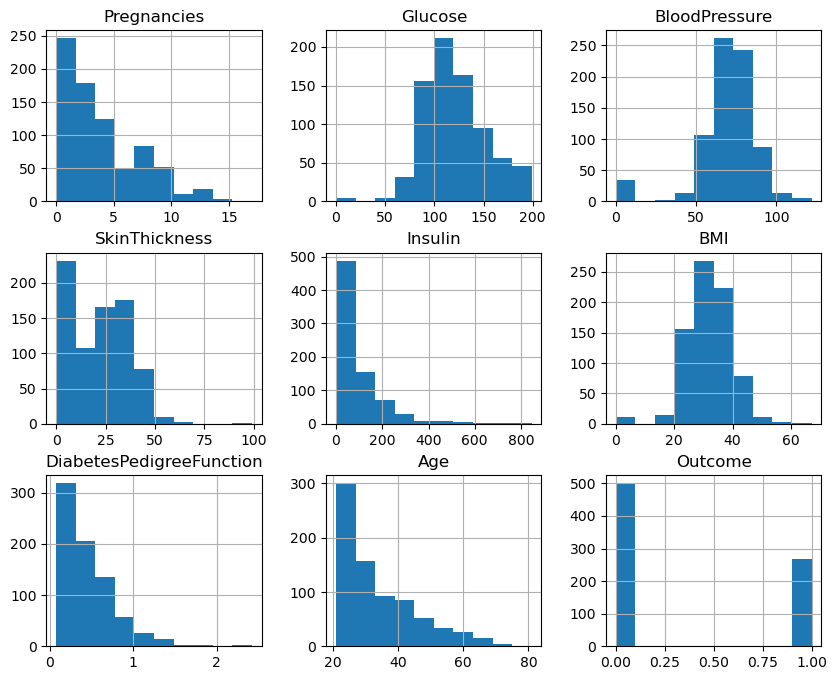

In [ ]:
df.hist(figsize=(10,8))
plt.show()

The histograms show how each medical feature is distributed among patients. We can observe that glucose and BMI have a wider spread, which means patients have different levels and these features vary significantly. Age is slightly right-skewed, indicating more younger patients than older ones. The Outcome column shows two classes (0 and 1), meaning both diabetic and non-diabetic cases are present. These distributions help us understand the range of values and ensure the data is suitable for model training.

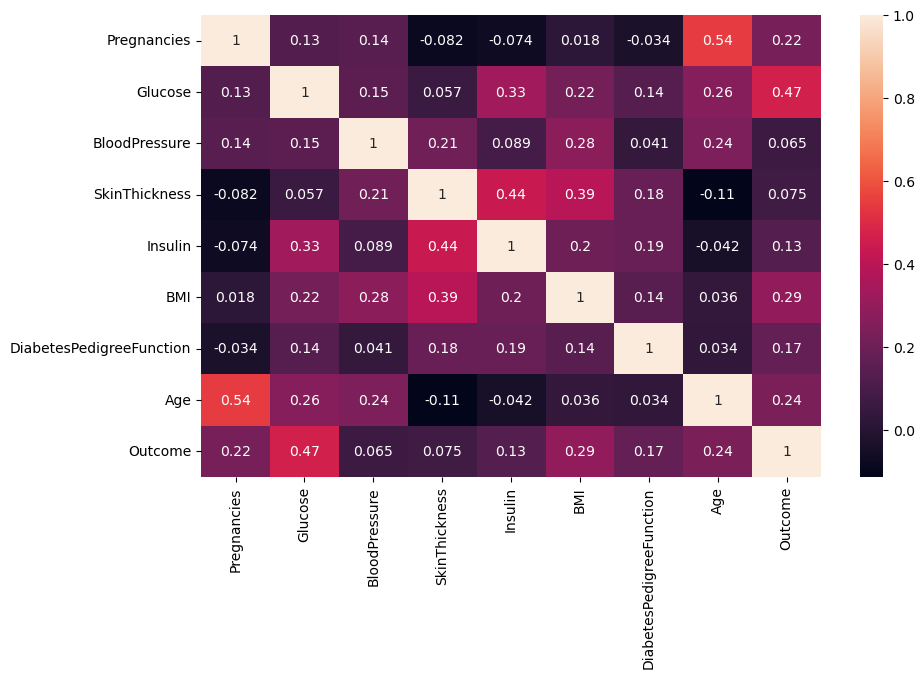

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

The heatmap shows how different features are related to each other. We can observe that some features have a stronger relationship with the target variable, which means they may play an important role in predicting diabetes. If two features are highly related to each other, it may cause redundancy in the model. This step helps us understand which features are useful and how they interact with each other.

## Data Preprocessing

Some columns in the dataset contain zero values, which are not realistic for medical data. For example, a glucose level or BMI cannot be zero in real life. So, we replace these values with the average of that column. This makes the dataset more accurate and usable. If we do not fix these values, the model may learn incorrect patterns and give poor results.

In [ ]:
# Replace zero values
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].mean())

## Defining Variables

In this step, we separate the dataset into input features and the target variable. The input features are used to predict whether a person has diabetes, while the target variable contains the actual outcome.

In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

## Splitting the Data

The dataset is divided into training and testing sets. The training data is used to build the model, while the testing data is used to evaluate how well the model performs on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Logistic Regression Model

Logistic regression is used when we want to predict categories, such as whether a person has diabetes or not. Instead of predicting a number, it predicts a probability between 0 and 1. If the probability is high, the model predicts that the person has diabetes. If it is low, it predicts no diabetes. This method helps us make clear yes or no decisions based on the data.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

## Model Evaluation

After building the model, we check how well it performs using different metrics. Accuracy shows how many predictions are correct overall. Precision tells us how many predicted positive cases are actually correct. Recall shows how many actual positive cases we correctly identified. These metrics help us understand whether the model is reliable, especially in medical situations where correct prediction is important.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7662337662337663
Precision: 0.6862745098039216
Recall: 0.6363636363636364
F1 Score: 0.660377358490566


## ROC Curve

The ROC curve helps us understand how well the model separates the two classes. It shows the balance between correctly identifying positive cases and avoiding false alarms. A better model will have a curve closer to the top-left corner. The ROC score gives a single value to measure performance, where a higher value means better prediction ability.

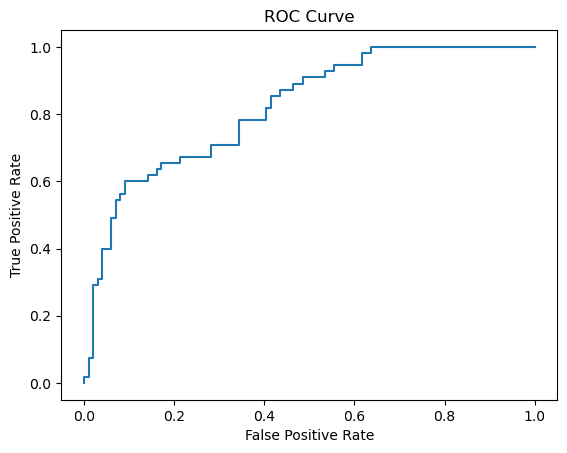

ROC AUC: 0.8202020202020203


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC AUC:", roc_auc_score(y_test, y_prob))

The ROC curve shows how well the model can distinguish between patients with and without diabetes. A curve that is closer to the top-left corner indicates better performance. The area under the curve gives a single value to measure accuracy, where a higher value means the model is performing well. This helps us understand the overall quality of the classification model.

## Interpretation of Coefficients

The coefficients show how each feature affects the probability of diabetes. A positive coefficient means the feature increases the chances of diabetes, while a negative coefficient means it decreases the chances. This helps in understanding which factors are most important.

In [ ]:
coef_df = pd.DataFrame(model.coef_[0], X.columns, columns=['Coefficient'])
coef_df

,Coefficient
Pregnancies,0.067306
Glucose,0.038112
BloodPressure,-0.014664
SkinThickness,0.001606
Insulin,-0.002059
BMI,0.107928
DiabetesPedigreeFunction,0.576694
Age,0.034618


## Interview Questions

Precision measures how many predicted positive cases are actually correct. Recall measures how many actual positive cases are correctly identified. Both are important depending on the problem.

Cross-validation is a technique used to test the model on different subsets of data. It helps ensure that the model performs well on unseen data and reduces the risk of overfitting.

## Conclusion

In this assignment, we used logistic regression to predict whether a person has diabetes based on medical data. We first cleaned the dataset and explored it to understand patterns. Then we built a model and tested its performance. The results show that features like glucose level and BMI play an important role. This model can help in early detection and decision-making in healthcare situations.